# Drug coverage & learnability — CTRPv2 × SCP542

Quantifies, **per drug**, how many cell lines have a measurement (coverage) and how much the
response actually varies across lines (variance) — the two things that decide whether a drug is
*learnable*. Then links coverage/variance to the trained model's per-drug performance ("does it
beat the per-drug-mean baseline?").

Why this matters: viability clusters near 1.0, so a drug is only learnable if it has (a) enough
cell lines screened against it, and (b) real spread in response. Low-coverage / low-variance drugs
are the ones no model can beat the baseline on.

In [33]:
from pathlib import Path
import glob, os
import numpy as np, pandas as pd, scanpy as sc
import matplotlib.pyplot as plt

TARGETS = Path('/Users/selin/Desktop/OncoTox/data/processed/scRNAseq_SCP542/hvg5000/'
               'SCP542_CCLE_scGPT_human_embeddings_with_targets.h5ad')
a = sc.read_h5ad(TARGETS, backed='r')
drugs = list(a.uns['ctrp_drugs'])
print(f'{len(drugs)} drugs, {a.n_obs} cells')

545 drugs, 53513 cells


## 1. Collapse to one row per cell line

The label is constant within a cell line (bulk value broadcast to its cells), so we take one
representative cell per line → a (cell line × drug) viability matrix.

In [34]:
cl = a.obs['Cell_line'].astype(str).values
M = np.asarray(a.obsm['M_ctrp']).astype(bool)          # observed mask (n_cells, 545)
Y = np.asarray(a.obsm['Y_ctrp'], dtype=float)          # viability, NaN/0 where missing

rep = pd.DataFrame({'cl': cl}).drop_duplicates('cl')   # first cell per line, preserves order
line_names = rep['cl'].values
rows = rep.index.values
M_line = M[rows]                                       # (n_lines, 545)
Y_line = np.where(M_line, Y[rows], np.nan)             # mask-truth: NaN where not screened

n_lines = len(line_names)
lines_with_any = int(M_line.any(1).sum())
print(f'{n_lines} unique SCP542 cell lines; {lines_with_any} overlap CTRPv2 (have >=1 drug label)')

198 unique SCP542 cell lines; 180 overlap CTRPv2 (have >=1 drug label)


## 2. Per-drug coverage (how many cell lines measured each drug)

In [35]:
cov = M_line.sum(0)                                     # lines per drug
resp_std = np.nanstd(Y_line, axis=0)                   # response spread across lines
resp_mean = np.nanmean(Y_line, axis=0)
drug_df = pd.DataFrame({
    'drug': drugs,
    'n_lines': cov,
    'pct_of_overlap': 100 * cov / lines_with_any,
    'resp_mean': resp_mean,
    'resp_std': resp_std,
}).sort_values('n_lines', ascending=False).reset_index(drop=True)

print('coverage summary (lines per drug):')
print(drug_df['n_lines'].describe()[['min','25%','50%','75%','max']].round(1).to_string())
print(f"\ndrugs measured on ALL {lines_with_any} overlapping lines: "
      f"{(cov == lines_with_any).sum()} / {len(drugs)}")
print(f"drugs measured on >=90% of overlapping lines: {(drug_df['pct_of_overlap']>=90).sum()}")
print(f"drugs measured on <50% of overlapping lines:  {(drug_df['pct_of_overlap']<50).sum()}")

coverage summary (lines per drug):
min     15.0
25%    151.0
50%    171.0
75%    174.0
max    179.0

drugs measured on ALL 180 overlapping lines: 0 / 545
drugs measured on >=90% of overlapping lines: 382
drugs measured on <50% of overlapping lines:  80


### Distribution of per-drug coverage

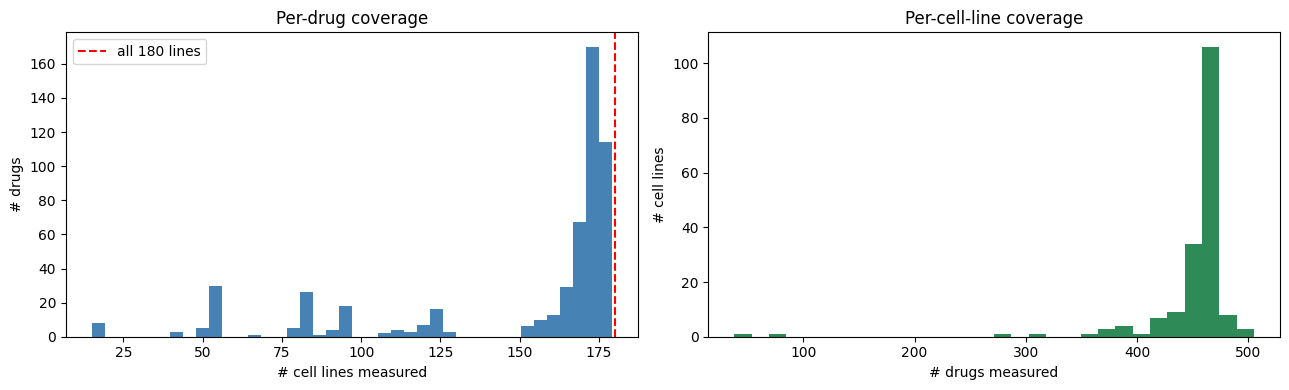

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(drug_df['n_lines'], bins=40, color='steelblue')
ax[0].axvline(lines_with_any, color='red', ls='--', label=f'all {lines_with_any} lines')
ax[0].set_xlabel('# cell lines measured'); ax[0].set_ylabel('# drugs'); ax[0].set_title('Per-drug coverage'); ax[0].legend()
ax[1].hist(M_line.sum(1)[M_line.any(1)], bins=30, color='seagreen')
ax[1].set_xlabel('# drugs measured'); ax[1].set_ylabel('# cell lines'); ax[1].set_title('Per-cell-line coverage')
plt.tight_layout(); plt.show()

### Most- and least-covered drugs

In [37]:
print('TOP 10 coverage:'); print(drug_df.head(10).to_string(index=False))
print('\nBOTTOM 10 coverage:'); print(drug_df.tail(10).to_string(index=False))

TOP 10 coverage:
         drug  n_lines  pct_of_overlap  resp_mean  resp_std
     snx-2112      179       99.444444   0.720657  0.169307
    ceranib-2      178       98.888889   0.777768  0.102221
     curcumin      178       98.888889   0.820567  0.072850
    nsc632839      178       98.888889   0.838148  0.087249
      osi-027      178       98.888889   0.810007  0.103320
  vincristine      178       98.888889   0.599117  0.200408
   decitabine      178       98.888889   0.959545  0.083563
    pazopanib      178       98.888889   0.906615  0.101629
   pha-793887      178       98.888889   0.817539  0.117471
brd-k63431240      178       98.888889   0.732459  0.094820

BOTTOM 10 coverage:
                         drug  n_lines  pct_of_overlap  resp_mean  resp_std
                brd-k09344309       41       22.777778   1.074937  0.093111
                  abiraterone       40       22.222222   1.002150  0.069242
                brd-k01737880       16        8.888889   0.926061  0.13049

## 3. Coverage vs response variance

Coverage alone isn't enough — a drug also needs **spread** in response to be learnable. High
coverage + high `resp_std` = easiest; low on either = hard.

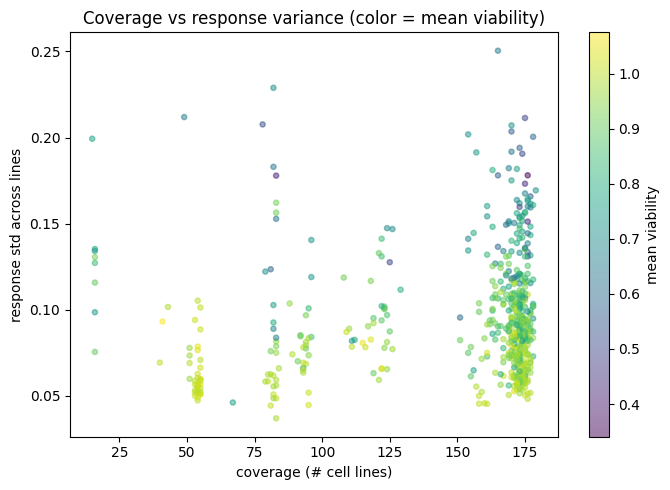

low-variance drugs (std < 0.05) — little to learn even if well covered: 14


In [38]:
fig, ax = plt.subplots(figsize=(7, 5))
sc_ = ax.scatter(drug_df['n_lines'], drug_df['resp_std'], s=14, alpha=0.5, c=drug_df['resp_mean'], cmap='viridis')
ax.set_xlabel('coverage (# cell lines)'); ax.set_ylabel('response std across lines')
ax.set_title('Coverage vs response variance (color = mean viability)')
fig.colorbar(sc_, label='mean viability'); plt.tight_layout(); plt.show()
print('low-variance drugs (std < 0.05) — little to learn even if well covered:',
      int((drug_df['resp_std'] < 0.05).sum()))

## 4. Does coverage / variance predict model performance?

Merge with the latest multi-task run's `per_drug_results.csv` (per-drug `model_val_mse`,
`baseline_val_mse`, `delta`, `n_val`). `delta < 0` ⇒ the model beats the per-drug-mean baseline.

In [39]:
runs = sorted(glob.glob('/Users/selin/PycharmProjects/OncoTox/runs/*_all_drugs/per_drug_results.csv'), key=os.path.getmtime)
assert runs, 'no *_all_drugs run found — train a K=545 model first'
run_csv = runs[-1]
print('using', run_csv)
pdr = pd.read_csv(run_csv)
m = drug_df.merge(pdr, on='drug', how='inner')
m['beats'] = m['delta_model_minus_baseline'] < 0 if 'delta_model_minus_baseline' in m else (m['model_val_mse'] < m['baseline_val_mse'])
print(f"{m['beats'].sum()} / {len(m)} heads beat baseline in this run")

using /Users/selin/PycharmProjects/OncoTox/runs/20260614_205926_multitask_X_pca_all_drugs/per_drug_results.csv
196 / 545 heads beat baseline in this run


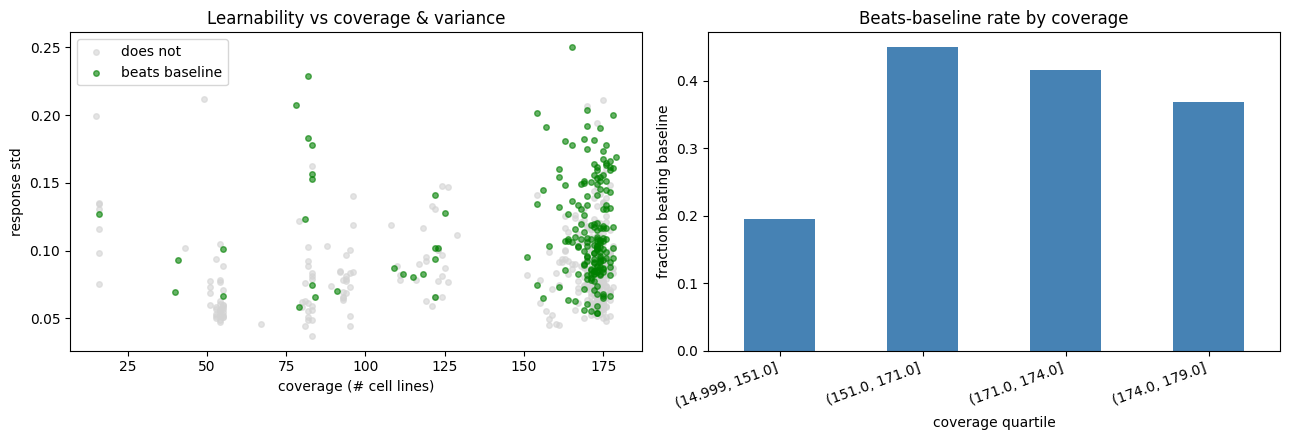

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for beats, sub in m.groupby('beats'):
    ax[0].scatter(sub['n_lines'], sub['resp_std'], s=16, alpha=0.6,
                  label='beats baseline' if beats else 'does not', color='green' if beats else 'lightgray')
ax[0].set_xlabel('coverage (# cell lines)'); ax[0].set_ylabel('response std'); ax[0].set_title('Learnability vs coverage & variance'); ax[0].legend()

# beats-baseline rate by coverage quartile
m['cov_bin'] = pd.qcut(m['n_lines'], 4, duplicates='drop')
rate = m.groupby('cov_bin')['beats'].mean()
rate.plot(kind='bar', ax=ax[1], color='steelblue')
ax[1].set_ylabel('fraction beating baseline'); ax[1].set_xlabel('coverage quartile'); ax[1].set_title('Beats-baseline rate by coverage')
plt.setp(ax[1].get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig('outputs/drug_coverage.png')
plt.show()

## 5. Easiest vs hardest drugs to predict

In [41]:
easy = m.sort_values('delta_model_minus_baseline').head(10)[['drug','n_lines','resp_std','model_val_mse','baseline_val_mse','n_val']]
hard = m.sort_values('delta_model_minus_baseline', ascending=False).head(10)[['drug','n_lines','resp_std','model_val_mse','baseline_val_mse','n_val']]
print('EASIEST (largest model gain over baseline):'); print(easy.to_string(index=False))
print('\nHARDEST (model worse than baseline):'); print(hard.to_string(index=False))

EASIEST (largest model gain over baseline):
                            drug  n_lines  resp_std  model_val_mse  baseline_val_mse  n_val
                          gsk-j4       16  0.127143       0.000186          0.011351    221
                   brd-k09344309       41  0.093111       0.009965          0.015694   1279
                           qs-11       55  0.101253       0.008351          0.012296   2005
                    oligomycin a      165  0.250433       0.087044          0.090586   6144
                       docetaxel       78  0.207613       0.044063          0.047262   3272
                       nilotinib      175  0.116374       0.011495          0.013846   6816
  epigallocatechin-3-monogallate      168  0.108781       0.014364          0.016342   6816
                           ml312       55  0.066277       0.006343          0.008279   2005
                     gemcitabine      154  0.201814       0.029424          0.031124   5751
erlotinib:plx-4032 (2:1 mol/mol)    

## 6. Learnability table — CTRPv2

Combine the two factors above into one per-drug **learnability** = `resp_std × (n_lines / overlap)`
— a drug needs both spread in response *and* enough cell lines screened. **Computed for every
CTRPv2 drug in the dataset** (data-driven; independent of which drugs OncoMLP trained on).
Sorted high→low and saved to `ctrp_drug_learnability.csv`. The `learnable` flag marks
`resp_std ≥ 0.05` **and** `≥ 50%` coverage (the two conditions from the notes; flat or
sparsely-screened drugs are unlearnable).

The empirical `beats_baseline` (+ `delta`, `n_val`) is **left-joined** from the latest trained run,
so it is **left empty for any drug the model did not train on**. Here the run covers all 545, so
none are empty.

In [42]:
# Learnability = enough coverage AND enough response spread (the two factors above) — no model
# needed. Computed for ALL CTRPv2 drugs in drug_df. Score: resp_std x (n_lines / overlap).
lrn = drug_df.copy()
lrn['cov_frac'] = lrn['n_lines'] / lines_with_any
lrn['learnability'] = (lrn['resp_std'] * lrn['cov_frac']).round(5)
lrn['learnable'] = (lrn['resp_std'] >= 0.05) & (lrn['pct_of_overlap'] >= 50)

# attach the empirical check from section 4 (model vs per-drug-mean baseline) via LEFT join,
# so every drug is kept and beats_baseline is empty for any drug the model didn't train on.
lrn = lrn.merge(m[['drug', 'beats', 'delta_model_minus_baseline', 'n_val']], on='drug', how='left')
lrn = lrn.rename(columns={'beats': 'beats_baseline'})

lrn = lrn.sort_values('learnability', ascending=False).reset_index(drop=True)
lrn.insert(0, 'rank', lrn.index + 1)
lrn = lrn[['rank', 'drug', 'n_lines', 'pct_of_overlap', 'resp_mean', 'resp_std',
           'learnability', 'learnable', 'beats_baseline', 'delta_model_minus_baseline', 'n_val']]
lrn.to_csv('outputs/ctrp_drug_learnability.csv', index=False)
n_eval = int((lrn['beats_baseline'] == True).sum())
n_empty = int(lrn['beats_baseline'].isna().sum())
print(f'saved ctrp_drug_learnability.csv  ({len(lrn)} drugs, '
      f'{int(lrn["learnable"].sum())} flagged learnable, '
      f'{n_eval} beat baseline, {n_empty} not trained -> empty beats_baseline)')
print('\nMOST learnable:'); print(lrn.head(10).to_string(index=False))
print('\nLEAST learnable:'); print(lrn.tail(10).to_string(index=False))

saved ctrp_drug_learnability.csv  (545 drugs, 459 flagged learnable, 196 beat baseline, 0 not trained -> empty beats_baseline)

MOST learnable:
 rank                                 drug  n_lines  pct_of_overlap  resp_mean  resp_std  learnability  learnable  beats_baseline  delta_model_minus_baseline  n_val
    1                         oligomycin a      165       91.666667   0.655851  0.250433       0.22956       True            True                   -0.003541   6144
    2                            sb-743921      175       97.222222   0.498544  0.211352       0.20548       True           False                    0.000438   6816
    3                          vincristine      178       98.888889   0.599117  0.200408       0.19818       True            True                   -0.001532   7121
    4                                ml210      170       94.444444   0.728607  0.207061       0.19556       True           False                    0.002402   7015
    5                          

## 7. Same analysis for GDSC2 (LN_IC50)

Same coverage × spread learnability ranking, adapted to **GDSC2** with **LN_IC50** as the response.
Unlike the CTRPv2 section (anchored to the SCP542 cells we train on), here the SCP542 overlap is
irrelevant — learnability is an intrinsic property of the GDSC2 screen — so coverage and spread are
computed over **all GDSC2 cell lines**. One LN_IC50 per (drug, line) (duplicate experiments
averaged), then `learnability = ic50_std × (n_lines / total_gdsc_lines)`. Saved to
`gdsc_drug_learnability.csv`. (LN_IC50 is an unbounded log scale, so the `learnable` std threshold
here is 0.5, not 0.05.)

In [43]:
# GDSC2 learnability over the FULL GDSC2 screen (SCP542 overlap is irrelevant here).
g = pd.read_excel('../data/GDSC2_fitted_dose_response_27Oct23.xlsx')
g['cl_norm'] = (g['CELL_LINE_NAME'].astype(str).str.strip().str.lower()
                .str.replace('-', '', regex=False))
n_total = g['cl_norm'].nunique()          # all GDSC2 cell lines
print(f'GDSC2: {n_total} cell lines, {g["DRUG_NAME"].nunique()} drugs')

# one LN_IC50 per (drug, line): average duplicate experiments
pair = g.groupby(['DRUG_NAME', 'cl_norm'])['LN_IC50'].mean().reset_index()
gd = (pair.groupby('DRUG_NAME')
      .agg(n_lines=('cl_norm', 'nunique'),
           ic50_mean=('LN_IC50', 'mean'),
           ic50_std=('LN_IC50', 'std'))
      .reset_index())
gd['pct_of_lines'] = (100 * gd['n_lines'] / n_total).round(2)
gd['cov_frac'] = gd['n_lines'] / n_total
gd['learnability'] = (gd['ic50_std'] * gd['cov_frac']).round(5)          # spread x coverage
gd['learnable'] = (gd['ic50_std'] >= 0.5) & (gd['pct_of_lines'] >= 50)   # LN scale -> 0.5
for c in ['ic50_mean', 'ic50_std']:
    gd[c] = gd[c].round(5)
gd = (gd.rename(columns={'DRUG_NAME': 'drug'})
        .sort_values('learnability', ascending=False).reset_index(drop=True))
gd.insert(0, 'rank', gd.index + 1)
gd = gd[['rank', 'drug', 'n_lines', 'pct_of_lines', 'ic50_mean', 'ic50_std',
         'learnability', 'learnable']]
gd.to_csv('outputs/gdsc_drug_learnability.csv', index=False)
print(f'saved gdsc_drug_learnability.csv  ({len(gd)} drugs, '
      f'{int(gd["learnable"].sum())} flagged learnable)')
print('\nMOST learnable:'); print(gd.head(10).to_string(index=False))
print('\nLEAST learnable:'); print(gd.tail(10).to_string(index=False))

GDSC2: 967 cell lines, 286 drugs
saved gdsc_drug_learnability.csv  (286 drugs, 270 flagged learnable)

MOST learnable:
 rank         drug  n_lines  pct_of_lines  ic50_mean  ic50_std  learnability  learnable
    1  Gemcitabine      958         99.07   -0.76983   3.00935       2.98134       True
    2      BI-2536      921         95.24   -1.15511   2.43111       2.31547       True
    3    Dasatinib      960         99.28    1.28345   2.31657       2.29980       True
    4 Methotrexate      879         90.90    0.34976   2.48466       2.25855       True
    5   Trametinib      964         99.69    0.21726   2.25332       2.24633       True
    6    Alisertib      947         97.93    1.58833   2.28836       2.24103       True
    7  Talazoparib      954         98.66    2.76683   2.21318       2.18343       True
    8    PD0325901      966         99.90    1.34301   2.13999       2.13778       True
    9    Docetaxel      966         99.90   -3.58806   2.13255       2.13035       True
 

## Target distribution — why the task is hard (data only, no training)

The learning ceiling is set by the **label**, not the genes. Reading the CTRPv2 targets only
(gene-set-independent — shown for `all_genes`), collapsed to the real per **(cell line × drug)**
measurements (the bulk value is constant within a line, broadcast to its cells):

- **A — viability clusters near 1.0** (median 0.91; 75% of values ≥ 0.8). Predicting the constant is
  already strong, so absolute MSE is uninformative.
- **B — per-drug variability is modest** (median std 0.088); only **3%** of drugs are truly flat
  (std < 0.05). So *flatness alone removes very few heads*.
- **C — a loose coverage+std filter keeps 439/545 drugs** (cov ≥ 100 lines & std ≥ 0.05). Filtering on
  coverage+std alone barely shrinks the set — so a useful learnability rule needs to be **stricter**
  (higher std, or actual cross-line predictability), not just "drop the flat/low-coverage ones".
- **D — responses are squeezed into a narrow high band (~0.8–1.0)** for most drugs; only a few drugs
  show strong low-viability (sensitive) responses.

**Takeaway:** the signal to learn is *small between lines and compressed near 1.0*, and it is broadcast
identically to every cell of a line (no per-cell signal). Adding/removing genes can't add target
signal — which is exactly why the gene-set sweep (`07` §4) is flat. This motivates **learnability
filtering** as the next step, with a definition stricter than coverage+std.

observed (line x drug) values: 81172
  median viability 0.913; frac>=0.8 0.75; frac>=0.9 0.53
per-drug std median 0.088; frac flat (<0.05) 0.03
loose filter keeps 439/545 (cov>=100 & std>=0.05)


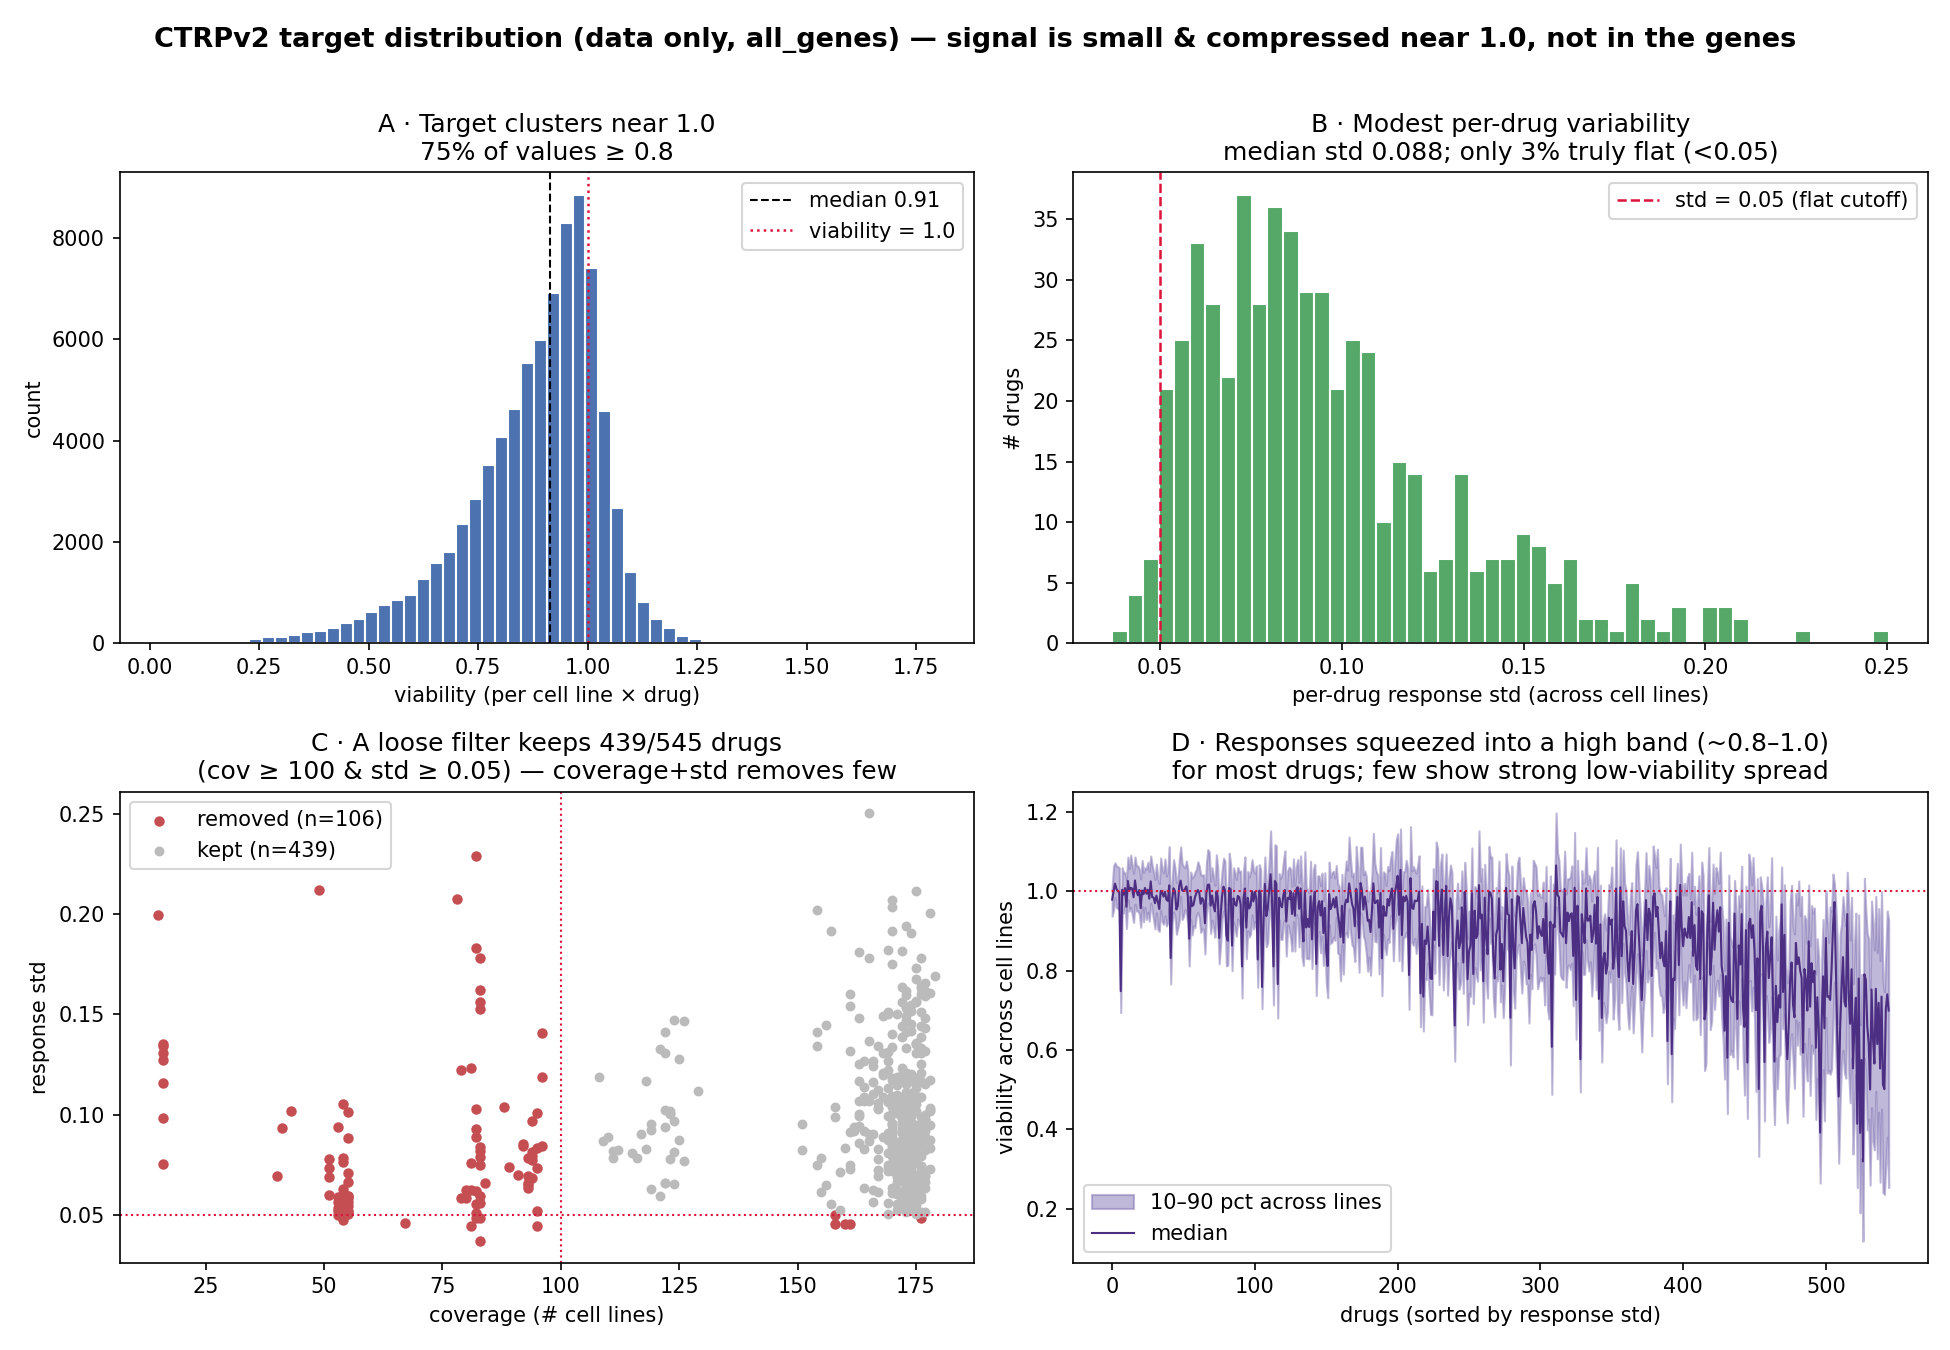

In [1]:
import sys
from pathlib import Path
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from scripts.preprocessing.layout import PipelinePaths

OUT = Path('outputs'); OUT.mkdir(exist_ok=True)

# Target is gene-set-independent; read all_genes in backed mode (big .X stays on disk).
ad = sc.read_h5ad(PipelinePaths.build(None, 'all_genes').targets_h5ad, backed='r')
lines = ad.obs['Cell_line'].astype(str).to_numpy()
Y = np.asarray(ad.obsm['Y_ctrp'], dtype=float)
M = np.asarray(ad.obsm['M_ctrp'], dtype=bool)
drugs = list(ad.uns['ctrp_drugs']); K = len(drugs)
uniq = np.unique(lines)

# Collapse to the real (cell line x drug) measurements. The bulk label is constant
# within a line (broadcast to its cells) -> per-line value = mean over observed cells.
V = np.full((len(uniq), K), np.nan)
for i, ln in enumerate(uniq):
    idx = np.flatnonzero(lines == ln); m = M[idx]
    has = m.any(0); cnt = m.sum(0); s = np.where(m, Y[idx], 0.0).sum(0)
    V[i, has] = s[has] / cnt[has]

obs_vals = V[np.isfinite(V)]
cov = np.isfinite(V).sum(0); std = np.nanstd(V, 0); fs = np.isfinite(std)
COV_MIN, STD_MIN = 100, 0.05
keep = (cov >= COV_MIN) & (std >= STD_MIN)
print(f"observed (line x drug) values: {obs_vals.size}")
print(f"  median viability {np.median(obs_vals):.3f}; frac>=0.8 {(obs_vals>=0.8).mean():.2f}; frac>=0.9 {(obs_vals>=0.9).mean():.2f}")
print(f"per-drug std median {np.nanmedian(std):.3f}; frac flat (<{STD_MIN}) {(std[fs]<STD_MIN).mean():.2f}")
print(f"loose filter keeps {int(keep.sum())}/{K} (cov>={COV_MIN} & std>={STD_MIN})")

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

a = ax[0, 0]
a.hist(obs_vals, bins=60, color="#4C72B0", edgecolor="white")
a.axvline(np.median(obs_vals), color="k", ls="--", lw=1, label=f"median {np.median(obs_vals):.2f}")
a.axvline(1.0, color="crimson", ls=":", lw=1.2, label="viability = 1.0")
a.set_xlabel("viability (per cell line x drug)"); a.set_ylabel("count")
a.set_title(f"A . Target clusters near 1.0\n{(obs_vals>=0.8).mean()*100:.0f}% of values >= 0.8"); a.legend()

b = ax[0, 1]
b.hist(std[fs], bins=50, color="#55A868", edgecolor="white")
b.axvline(STD_MIN, color="crimson", ls="--", lw=1.2, label=f"std = {STD_MIN} (flat cutoff)")
b.set_xlabel("per-drug response std (across cell lines)"); b.set_ylabel("# drugs")
b.set_title(f"B . Modest per-drug variability\nmedian std {np.nanmedian(std):.3f}; only {(std[fs]<STD_MIN).mean()*100:.0f}% truly flat"); b.legend()

c = ax[1, 0]
c.scatter(cov[~keep], std[~keep], s=16, c="#C44E52", label=f"removed (n={int((~keep).sum())})")
c.scatter(cov[keep], std[keep], s=14, c="#bbbbbb", label=f"kept (n={int(keep.sum())})")
c.axhline(STD_MIN, color="crimson", ls=":", lw=1); c.axvline(COV_MIN, color="crimson", ls=":", lw=1)
c.set_xlabel("coverage (# cell lines)"); c.set_ylabel("response std")
c.set_title(f"C . Loose filter keeps {int(keep.sum())}/{K} drugs\n(cov >= {COV_MIN} & std >= {STD_MIN}) - coverage+std removes few"); c.legend()

d = ax[1, 1]
order = np.argsort(np.where(fs, std, -1)); xs = np.arange(K)
lo = np.nanpercentile(V, 10, axis=0)[order]; hi = np.nanpercentile(V, 90, axis=0)[order]
md = np.nanmedian(V, axis=0)[order]
d.fill_between(xs, lo, hi, color="#8172B3", alpha=0.5, label="10-90 pct across lines")
d.plot(xs, md, color="#4C2E83", lw=1, label="median"); d.axhline(1.0, color="crimson", ls=":", lw=1)
d.set_xlabel("drugs (sorted by response std)"); d.set_ylabel("viability across cell lines")
d.set_title("D . Responses squeezed into a high band (~0.8-1.0)\nfor most drugs; few show strong low-viability spread"); d.legend(loc="lower left")

fig.suptitle("CTRPv2 target distribution (data only, all_genes) - signal is small & compressed near 1.0, not in the genes",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUT / "target_distribution.png", dpi=150); plt.show()